# Identifying Key Drivers of Customer Subscription in Bank Marketing Campaigns

**PROBLEM STATEMENT**

In today’s competitive banking industry, marketing campaigns play a crucial role in promoting financial products such as term deposits. However, not all marketing efforts lead to successful conversions, resulting in inefficient use of resources and suboptimal campaign performance.

In this case, management assumes that the communication channel (contact type), whether customers are contacted via telephone or
cellular, has a significant impact on customer decisions. However, this assumption has not yet been validated using data.

At the same time, other factors such as customer demographics, financial conditions, campaign intensity, and timing may also influence subscription outcomes. Without a clear understanding of these factors, the bank risks applying ineffective strategies, such as over-contacting customers or targeting the wrong segments.

Therefore, a data-driven analysis is needed to identify the key drivers of customer subscription and evaluate the effectiveness of current marketing strategies.


**OBJECTIVES**
This project aims to:

1. Identify key factors that influence customer subscription to term deposits
2. Analyze customer characteristics, financial conditions, and campaign strategies that affect conversion rates
3. Evaluate the effectiveness of marketing approaches, including contact frequency and timing
4. Validate the business assumption that contact type significantly impacts customer subscription using statistical testing
5. Provide actionable insights to improve campaign effectiveness and targeting strategy

## Data Preparation

Before conducting the analysis, the dataset was prepared through several steps to ensure data quality and reliability.

The required libraries were imported, including tools for data processing, visualization, and statistical analysis. The dataset was then retrieved from the UCI Machine Learning Repository (Bank Marketing Dataset).

### Import Library

In [ ]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

### Load Dataset

In [ ]:
# Load Dataset
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# Combine X and y
df = pd.concat([X, y], axis=1)

# metadata
print(bank_marketing.metadata)

# variable information
print(bank_marketing.variables)


{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

In [ ]:
# Data overview
print("Shape Data:", df.shape)
df

Shape Data: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,NaN,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,NaN,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,NaN,no


The dataset used in this analysis consists of 45,211 observations and 17 variables, representing customer information and marketing campaign data from a banking institution.

These variables are grouped into three main categories: customer characteristics, campaign-related information, and temporal features, with one target variable indicating whether a customer subscribes to a term deposit.

**Customer Information**

age — Age of the client (numeric)

job — Type of occupation (categorical)

marital — Marital status (categorical)

education — Education level (categorical)

default — Has credit in default (yes/no)

balance — Average yearly balance in euros (numeric)

housing — Has housing loan (yes/no)

loan — Has personal loan (yes/no)

**Campaign Information**

contact — Communication type (cellular / telephone)

duration — Last contact duration (in seconds)

campaign — Number of contacts during this campaign

poutcome — Outcome of the previous campaign

previous — Number of previous contacts

pdays — Days since last contact (-1 = not previously contacted)

**Time Variables**

day — Last contact day of the month

month — Last contact month

**Target Variable**

y — Indicates whether the client subscribed to a term deposit (yes/no)

## Data Cleaning and Transformation

Before proceeding to analysis, a data quality check was performed to identify missing values and inconsistencies.

Null Values per Column:
age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64


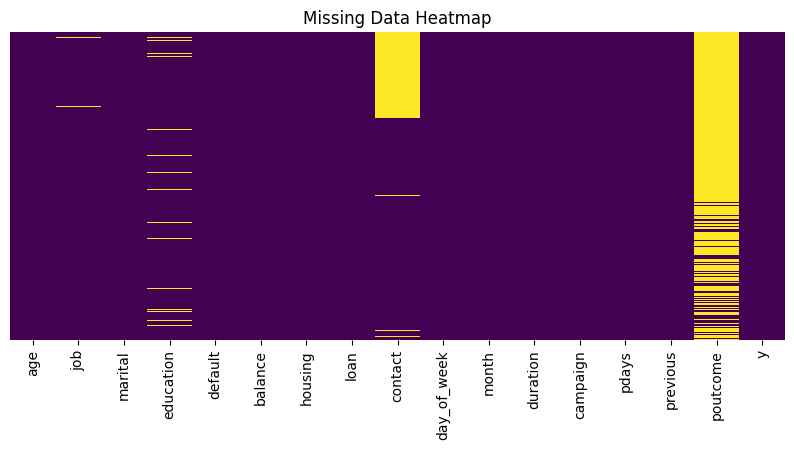

In [ ]:
# Check total nulls per column
print("Null Values per Column:")
print(df.isnull().sum())

# Visualizing nulls (Useful for presentation to show data quality)
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

In [ ]:
# Identifying Original Poutcome Distribution

# Use dropna=False to explicitly show the count of NaN values
poutcome_raw_counts = df['poutcome'].value_counts(dropna=False)
poutcome_raw_pct = df['poutcome'].value_counts(dropna=False, normalize=True) * 100

# Create the summary table
poutcome_raw_summary = pd.DataFrame({
    'Total Count': poutcome_raw_counts,
    'Percentage (%)': poutcome_raw_pct
})

print(poutcome_raw_summary)

          Total Count  Percentage (%)
poutcome                             
NaN             36959       81.747805
failure          4901       10.840282
other            1840        4.069806
success          1511        3.342107


In [ ]:
# List of features to analyze
features = ['job', 'education', 'contact']

# Frequency Analysis including 'unknown'
for col in features:
    counts = df[col].value_counts(dropna=False)
    pct = df[col].value_counts(dropna=False, normalize=True) * 100

    summary = pd.DataFrame({'Count': counts, 'Percentage (%)': pct})
    print(summary, "\n")

               Count  Percentage (%)
job                                 
blue-collar     9732       21.525735
management      9458       20.919688
technician      7597       16.803433
admin.          5171       11.437482
services        4154        9.188029
retired         2264        5.007631
self-employed   1579        3.492513
entrepreneur    1487        3.289023
unemployed      1303        2.882042
housemaid       1240        2.742695
student          938        2.074716
NaN              288        0.637013 

           Count  Percentage (%)
education                       
secondary  23202       51.319369
tertiary   13301       29.419831
primary     6851       15.153392
NaN         1857        4.107407 

           Count  Percentage (%)
contact                         
cellular   29285       64.774059
NaN        13020       28.798301
telephone   2906        6.427639 



The dataset shows that most variables have no missing values, indicating good overall data quality. However, several variables contain missing data with varying proportions.

The variable poutcome has a significantly high number of missing values, suggesting that a large portion of customers have no recorded outcome from previous campaigns. This likely indicates that many customers are new or have not been previously contacted.

Additionally, missing values are observed in contact, education, and job, although in smaller proportions compared to poutcome.

To better understand the distribution of missing data, a heatmap visualization was used, which confirms that missing values are concentrated in specific variables rather than randomly distributed across the dataset.

In [ ]:
# Handling Missing Value

# Handling Poutcome (The Strategic Decision)
# We treat NaN as 'new_customer' to preserve 81% of the data
df['poutcome'] = df['poutcome'].fillna('new_customer')

# Handling Job, Education, and Contact (The Refinement Decision)
# Since these are missing in smaller percentages, we drop these rows to ensure
# high-quality demographic analysis.
original_size = len(df)

# Drop rows where Job, Education, or Contact is NaN
df.dropna(subset=['job', 'education', 'contact'], inplace=True)

# Final Verification
new_size = len(df)
print(f"Original Rows: {original_size}")
print(f"Rows Removed: {original_size - new_size}")
print(f"Final Dataset Size: {new_size}")

# Check for any remaining Nulls
print("Remaining Null Values:")
print(df.isnull().sum())

Original Rows: 45211
Rows Removed: 14304
Final Dataset Size: 30907
Remaining Null Values:
age            0
job            0
marital        0
education      0
default        0
balance        0
housing        0
loan           0
contact        0
day_of_week    0
month          0
duration       0
campaign       0
pdays          0
previous       0
poutcome       0
y              0
dtype: int64


To handle missing values effectively, different strategies were applied based on the characteristics and importance of each variable.

The variable poutcome contains a large proportion of missing values. Instead of removing these records, missing values were treated as "new_customer" to preserve a significant portion of the dataset and retain meaningful information about customers with no prior campaign history.

For variables such as job, education, and contact, missing values were present in smaller proportions. To maintain data quality and ensure reliable analysis, rows with missing values in these key variables were removed.

This approach balances data preservation and data quality, ensuring that the dataset remains both representative and reliable for further analysis.

In [ ]:
# Check for Duplicate Rows
print(f"\nDuplicate rows found: {df.duplicated().sum()}")


Duplicate rows found: 0


No duplicate records were found in the dataset, indicating that each observation represents a unique customer entry. This ensures that the analysis is not biased by repeated data and reflects the actual distribution of customer behavior.

In [ ]:
# Data Transformation
# Create a numeric column for conversion to make calculations easier
df['conversion'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

To facilitate analysis, the target variable was transformed into a numerical format by creating a new variable called conversion.

The original target variable (y) indicates whether a customer subscribed to a term deposit (yes/no). This variable was converted into a binary format:

yes → 1

no → 0

This transformation allows easier calculation of conversion rates and enables more efficient comparison across different variables during analysis.

In [ ]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y,conversion
12657,27,management,single,secondary,no,35,no,no,cellular,4,jul,255,1,-1,0,new_customer,no,0
12658,54,blue-collar,married,primary,no,466,no,no,cellular,4,jul,297,1,-1,0,new_customer,no,0
12659,43,blue-collar,married,secondary,no,105,no,yes,cellular,4,jul,668,2,-1,0,new_customer,no,0
12660,31,technician,single,secondary,no,19,no,no,telephone,4,jul,65,2,-1,0,new_customer,no,0
12661,27,technician,single,secondary,no,126,yes,yes,cellular,4,jul,436,4,-1,0,new_customer,no,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,new_customer,yes,1
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,new_customer,yes,1
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes,1
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,new_customer,no,0


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is conducted to understand the underlying patterns, relationships, and key factors influencing customer subscription behavior.

This analysis focuses on three main aspects: customer demographics, financial conditions, and marketing campaign strategies, including contact type, campaign intensity, and timing.

By exploring these factors, we aim to identify patterns that can help improve marketing effectiveness and support data-driven decision-making.

/tmp/ipykernel_4738/3569263.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='y', data=df, palette=custom_palette)


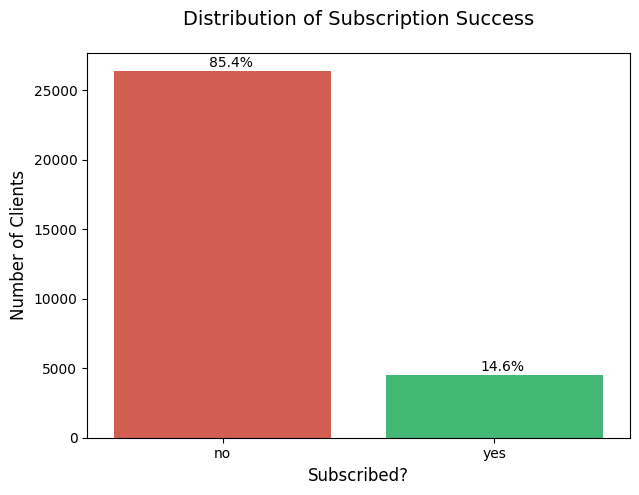

Overall Conversion Rate: 14.60%


In [ ]:
# Target Variable
plt.figure(figsize=(7, 5))
custom_palette = {'no': '#E74C3C', 'yes': '#2ECC71'}

ax = sns.countplot(x='y', data=df, palette=custom_palette)

total = len(df['y'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + (total * 0.01)
    ax.annotate(percentage, (x, y), fontsize=10)

plt.title('Distribution of Subscription Success', fontsize=14, pad=20)
plt.xlabel('Subscribed?', fontsize=12)
plt.ylabel('Number of Clients', fontsize=12)
plt.show()

conversion_rate = df['conversion'].mean() * 100
print(f"Overall Conversion Rate: {conversion_rate:.2f}%")

The distribution of the target variable shows that 85.4% of customers did not subscribe, while only 14.6% successfully subscribed to the term deposit.

This indicates a strong class imbalance and suggests that the overall effectiveness of the marketing campaign is relatively low.

From a business perspective, this highlights a significant opportunity to improve targeting strategies and campaign approaches in order to increase conversion rates.

/tmp/ipykernel_4738/2369698527.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0,0], x='y', y='age', data=df, palette=['#E74C3C', '#2ECC71'])
/tmp/ipykernel_4738/2369698527.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0,1], x=job_cr.values, y=job_cr.index, palette='viridis')
/tmp/ipykernel_4738/2369698527.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1,0], x=marital_cr.index, y=marital_cr.values, palette='magma')
/tmp/ipykernel_4738/2369698527.py:26: FutureWarning: 

Passing `palette` without assign

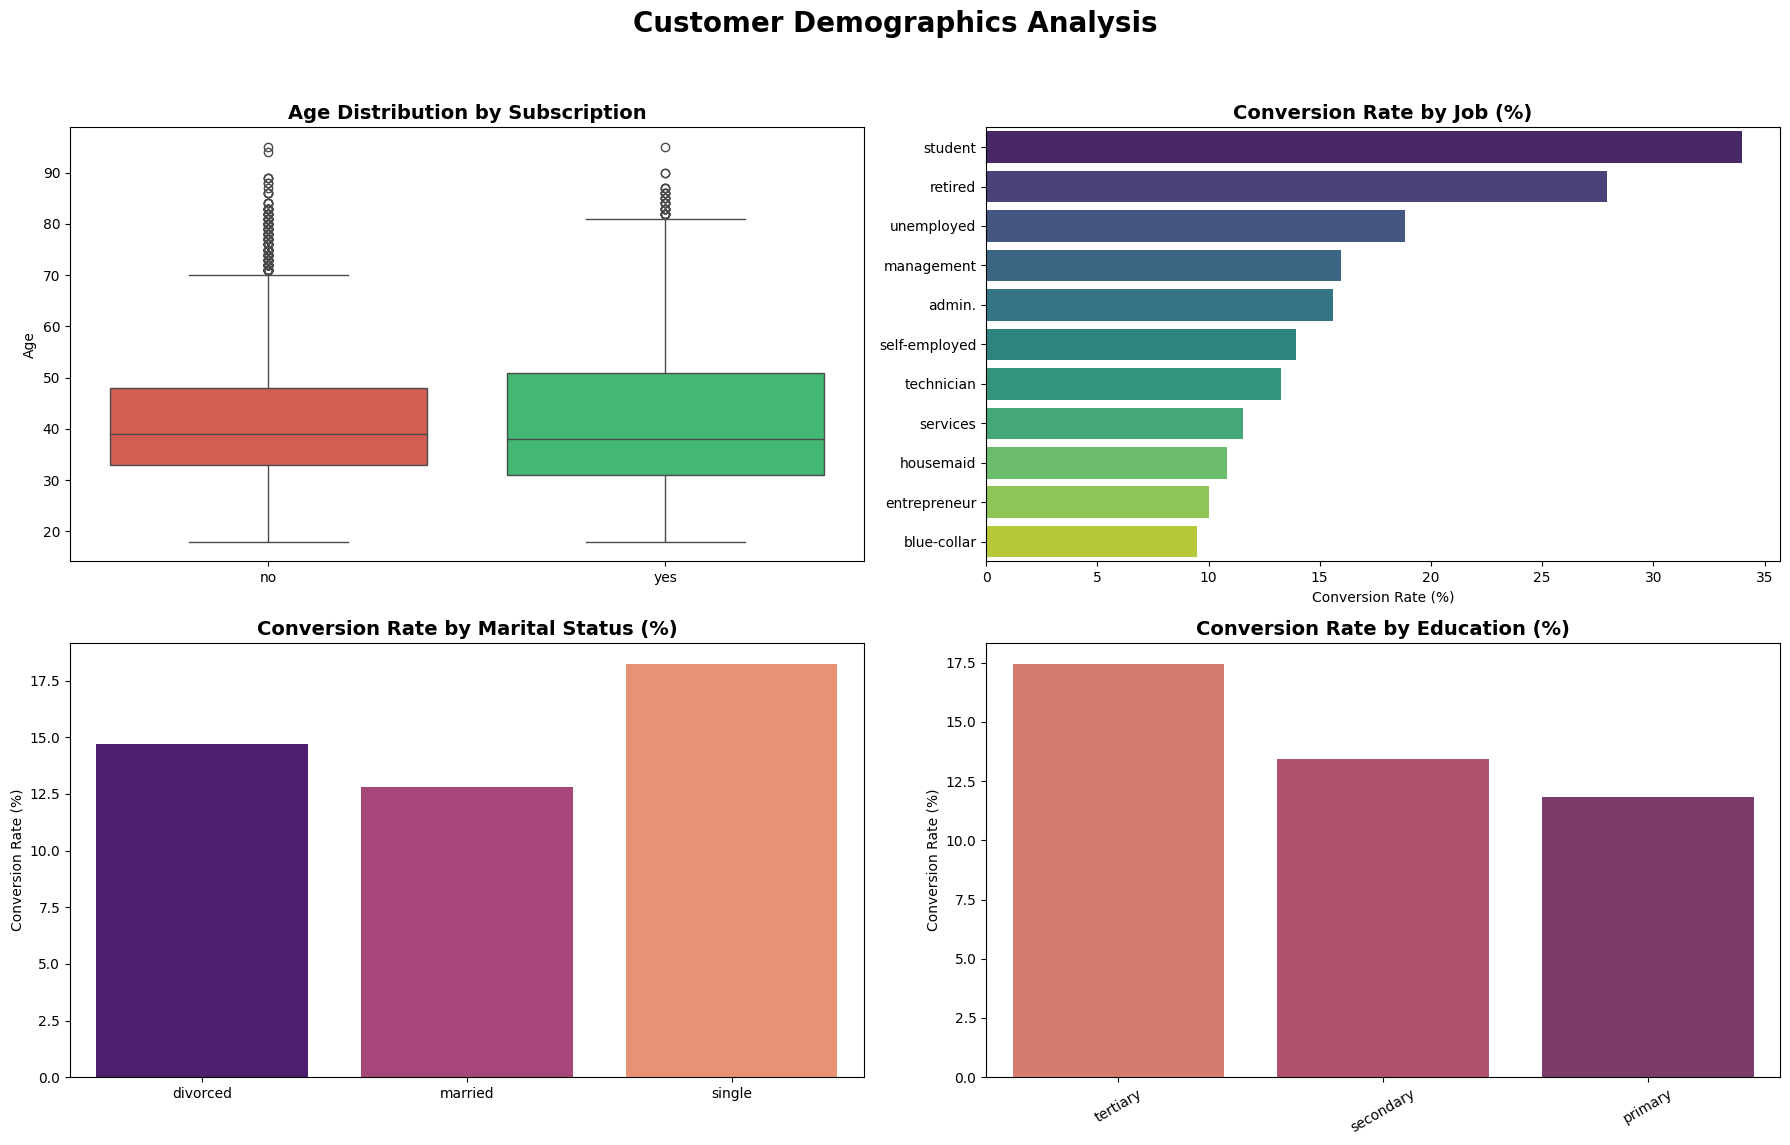

In [ ]:
# Customer Demographics Analysis
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Age Distribution (lebih clean pakai boxplot)
sns.boxplot(ax=axes[0,0], x='y', y='age', data=df, palette=['#E74C3C', '#2ECC71'])
axes[0,0].set_title('Age Distribution by Subscription', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Age')

# Job Conversion Rate
job_cr = df.groupby('job')['conversion'].mean().sort_values(ascending=False) * 100
sns.barplot(ax=axes[0,1], x=job_cr.values, y=job_cr.index, palette='viridis')
axes[0,1].set_title('Conversion Rate by Job (%)', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Conversion Rate (%)')
axes[0,1].set_ylabel('')

# Marital Status
marital_cr = df.groupby('marital')['conversion'].mean() * 100
sns.barplot(ax=axes[1,0], x=marital_cr.index, y=marital_cr.values, palette='magma')
axes[1,0].set_title('Conversion Rate by Marital Status (%)', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('')
axes[1,0].set_ylabel('Conversion Rate (%)')

# Education Level
edu_cr = df.groupby('education')['conversion'].mean().sort_values(ascending=False) * 100
sns.barplot(ax=axes[1,1], x=edu_cr.index, y=edu_cr.values, palette='flare')
axes[1,1].set_title('Conversion Rate by Education (%)', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('')
axes[1,1].set_ylabel('Conversion Rate (%)')
axes[1,1].tick_params(axis='x', rotation=30)

plt.suptitle('Customer Demographics Analysis', fontsize=20, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

The analysis shows that customer demographics have a noticeable influence on subscription behavior.

From the age distribution, there is no significant difference between subscribed and non-subscribed customers, indicating that **age alone is not a strong determining factor **in customer decisions.

However, differences become more evident when analyzing occupation. Certain job categories such as **students and retired individuals** exhibit significantly higher conversion rates compared to others, suggesting that these segments may have higher interest in term deposit products.

In terms of marital status, **single customers** show the highest conversion rate, followed by divorced and married customers. This may reflect differences in financial priorities and risk preferences.

Additionally, customers with **higher education levels**, particularly tertiary education, tend to have better conversion rates, indicating that financial awareness and knowledge may influence decision-making.

/tmp/ipykernel_4738/632472158.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=balance_cr.index, y=balance_cr.values, palette='Greens_d')


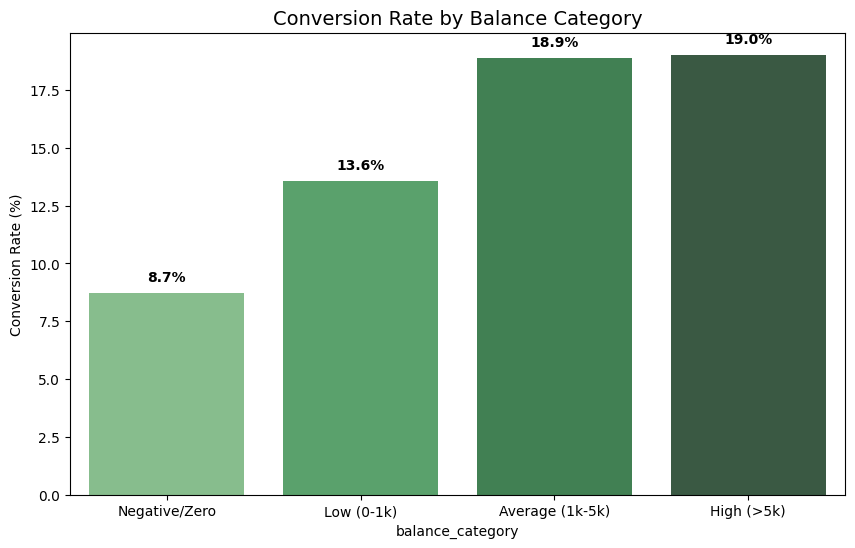

In [ ]:
# Conversion Rate by Balance Category
# Create Balance Groups (Binning)
def balance_group(x):
    if x <= 0: return 'Negative/Zero'
    elif x <= 1000: return 'Low (0-1k)'
    elif x <= 5000: return 'Average (1k-5k)'
    else: return 'High (>5k)'

df['balance_category'] = df['balance'].apply(balance_group)

# Calculate Conversion Rate per Balance Category
balance_order = ['Negative/Zero', 'Low (0-1k)', 'Average (1k-5k)', 'High (>5k)']
balance_cr = df.groupby('balance_category')['conversion'].mean().reindex(balance_order) * 100

# Plotting
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=balance_cr.index, y=balance_cr.values, palette='Greens_d')

# Add Labels
for i, v in enumerate(balance_cr.values):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.title('Conversion Rate by Balance Category', fontsize=14)
plt.ylabel('Conversion Rate (%)')
plt.show()

To better understand the impact of financial condition on customer behavior, the balance variable was grouped into categories.

This grouping was done to simplify interpretation and identify patterns more clearly, as raw numerical values can be difficult to analyze directly.

The balance was categorized into four groups:

* Negative/Zero

* Low (0–1k)
* Average (1k–5k)
* High (>5k)

The analysis shows a clear upward trend in conversion rates as balance increases:

* Customers with negative or zero balance have the lowest conversion rate (~8.7%)
* Conversion rate increases steadily for higher balance groups
Customers with average to high balance show the highest conversion (~18–19%)

Customers with better financial conditions are more likely to subscribe, indicating that financial capacity plays a significant role in decision-making.

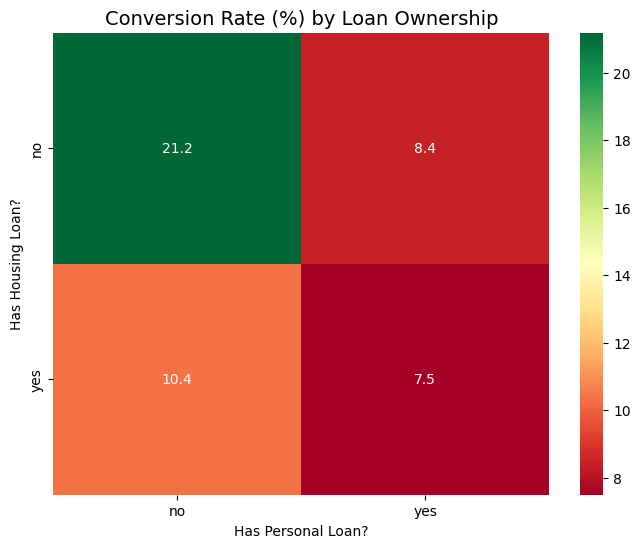

In [ ]:
# Impact of Loans (Housing & Personal) to Conversion Rate
# Creating a calculated table for visualization
loan_analysis = df.groupby(['housing', 'loan'])['conversion'].mean().unstack() * 100

plt.figure(figsize=(8, 6))
sns.heatmap(loan_analysis, annot=True, fmt=".1f", cmap='RdYlGn')
plt.title('Conversion Rate (%) by Loan Ownership', fontsize=14)
plt.xlabel('Has Personal Loan?')
plt.ylabel('Has Housing Loan?')
plt.show()

The analysis of loan ownership shows a strong pattern:

* Customers with no loans have the highest conversion rate (~21.2%)
* Customers with both housing and personal loans have the lowest conversion (~7.5%)

Customers with existing financial obligations are less likely to subscribe, suggesting that financial burden reduces their willingness to invest in additional financial products.

/tmp/ipykernel_4738/1933527078.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0,0], x='y', y='duration', data=df, palette=['#E74C3C','#2ECC71'])
/tmp/ipykernel_4738/1933527078.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0,1], x=contact_cr.index, y=contact_cr.values, palette='Set2')
/tmp/ipykernel_4738/1933527078.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1,0], x=pout_cr.index, y=pout_cr.values, palette='viridis')
/tmp/ipykernel_4738/1933527078.py:27: FutureWarning: 

Passing `palette` without a

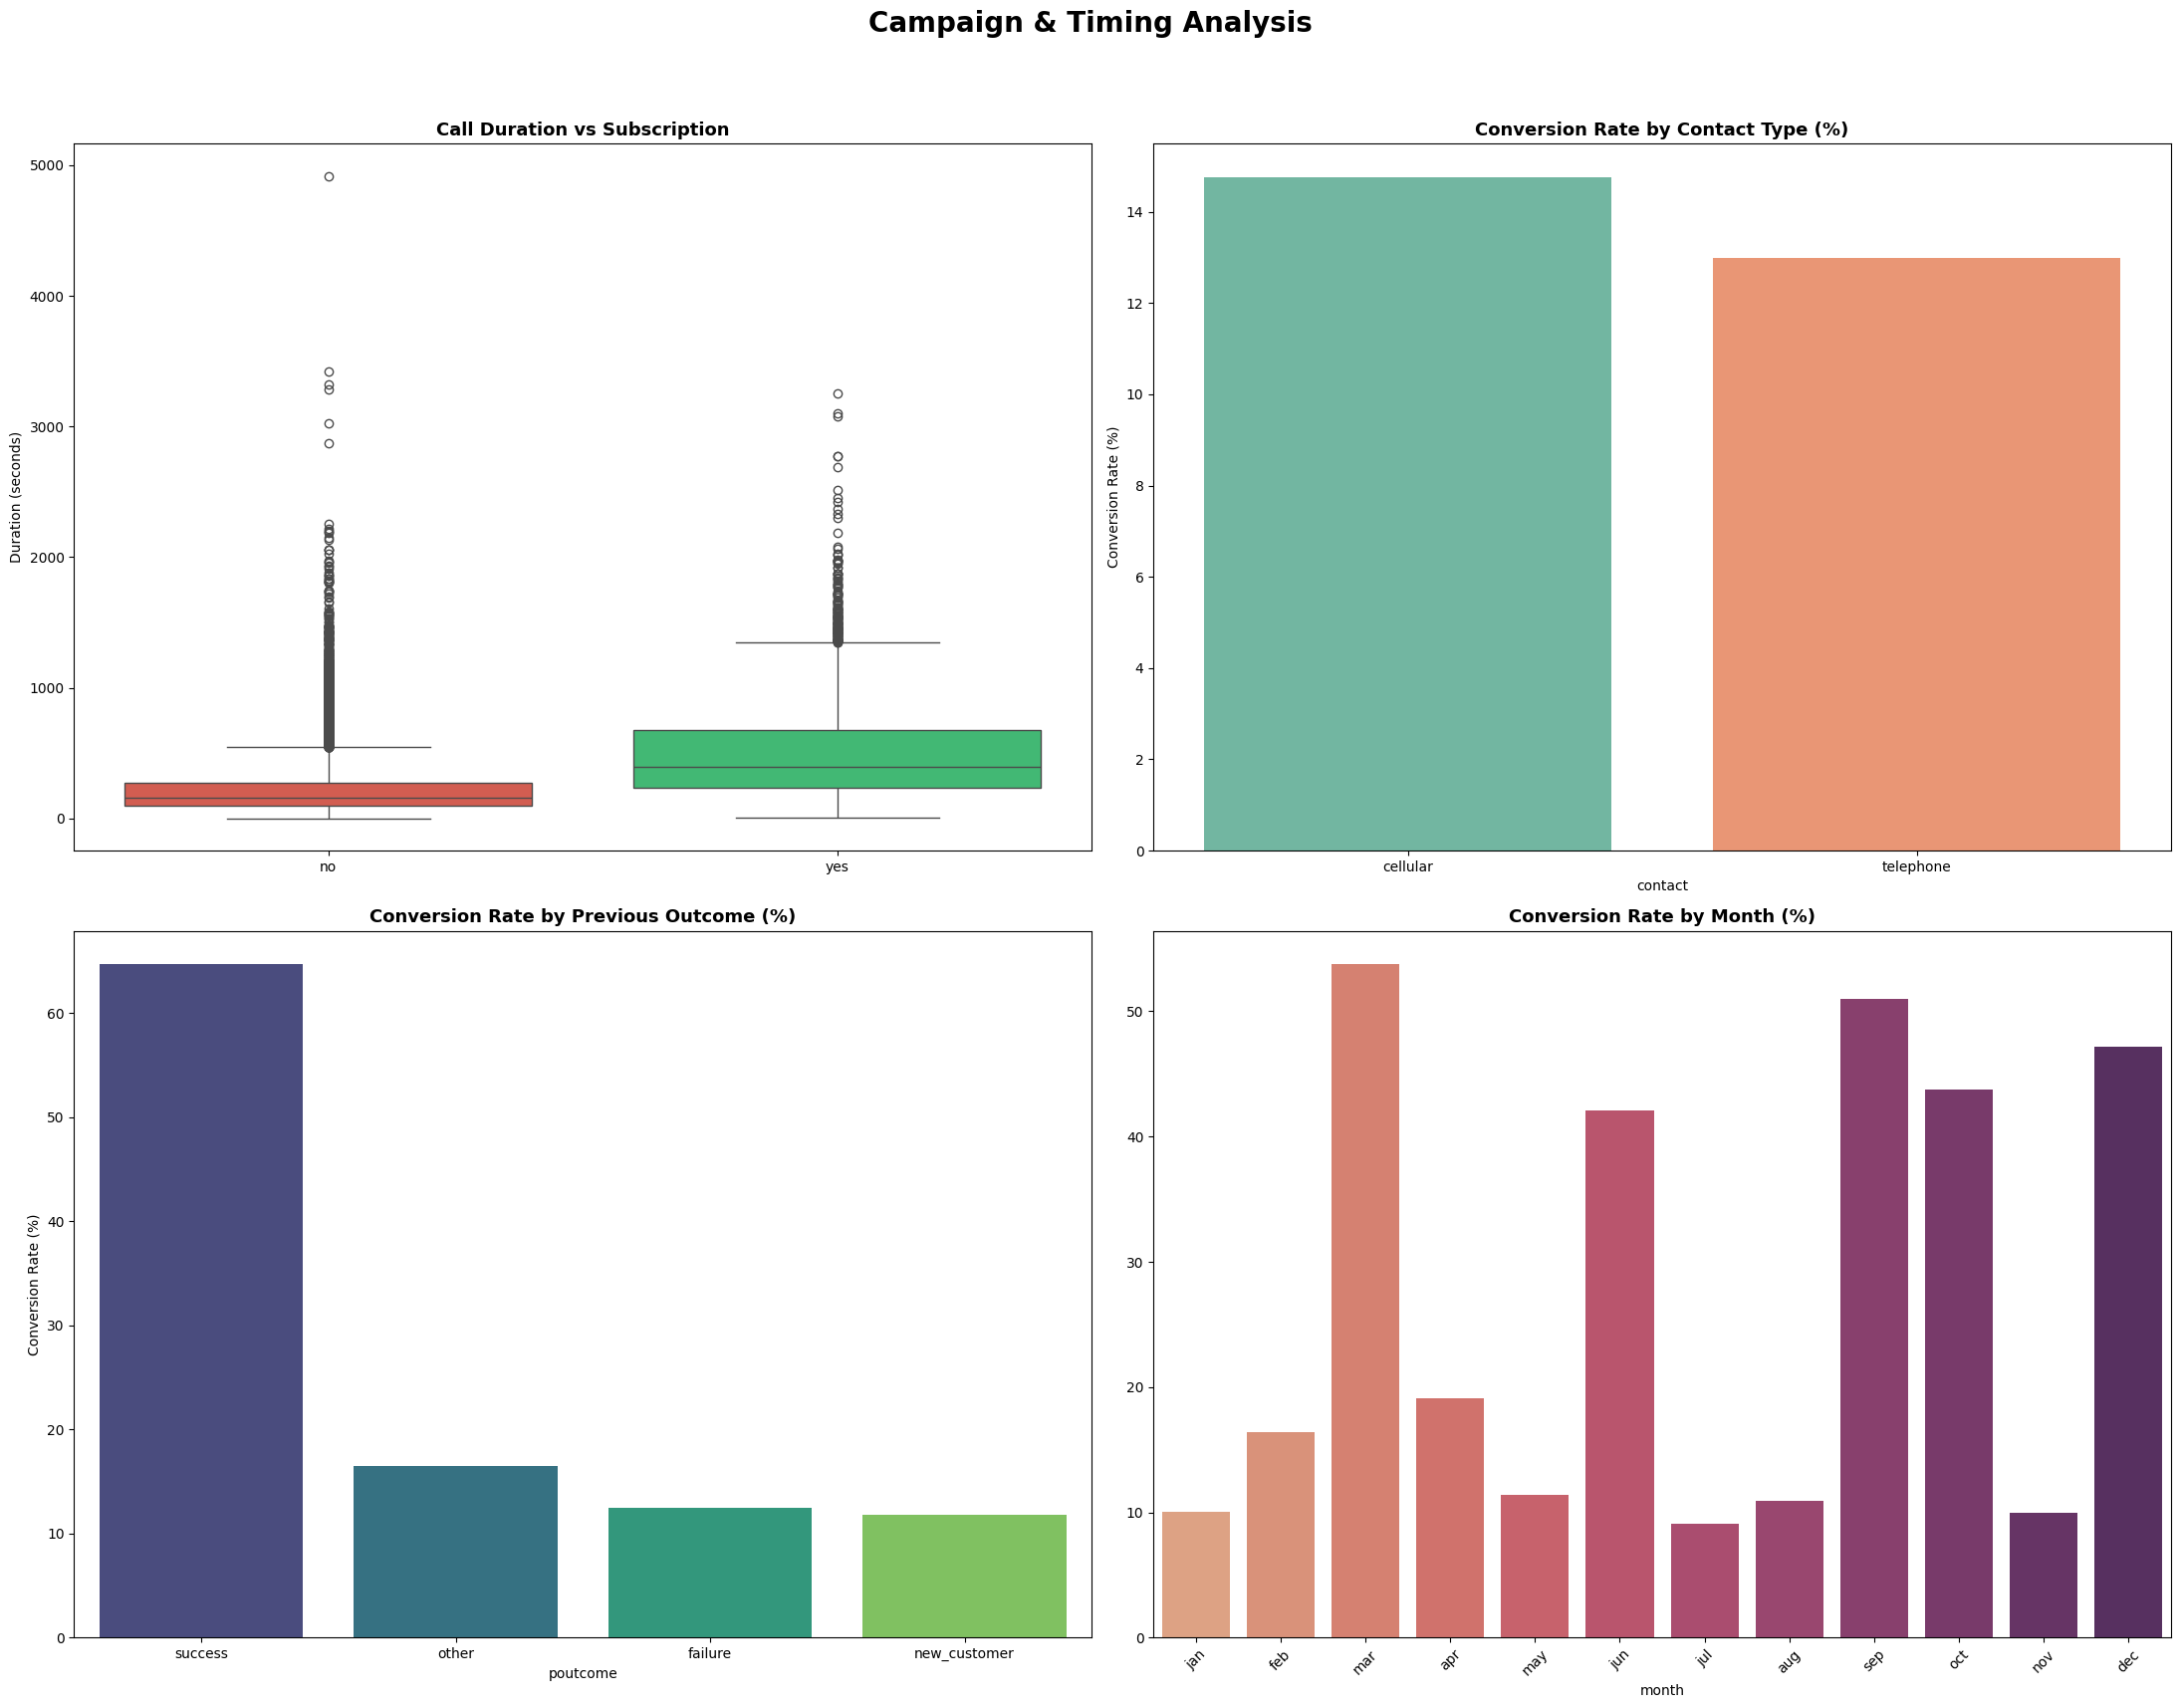

In [ ]:
# Campaign & Timing Analysis

fig, axes = plt.subplots(2, 2, figsize=(22, 18))

# Duration
sns.boxplot(ax=axes[0,0], x='y', y='duration', data=df, palette=['#E74C3C','#2ECC71'])
axes[0,0].set_title('Call Duration vs Subscription', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Duration (seconds)')

# Contact Type
contact_cr = df.groupby('contact')['conversion'].mean() * 100
sns.barplot(ax=axes[0,1], x=contact_cr.index, y=contact_cr.values, palette='Set2')
axes[0,1].set_title('Conversion Rate by Contact Type (%)', fontsize=13, fontweight='bold')
axes[0,1].set_ylabel('Conversion Rate (%)')

# Previous Outcome
pout_cr = df.groupby('poutcome')['conversion'].mean().sort_values(ascending=False) * 100
sns.barplot(ax=axes[1,0], x=pout_cr.index, y=pout_cr.values, palette='viridis')
axes[1,0].set_title('Conversion Rate by Previous Outcome (%)', fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('Conversion Rate (%)')

# Month Analysis
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_cr = df.groupby('month')['conversion'].mean().reindex(month_order) * 100

sns.barplot(ax=axes[1,1], x=month_cr.index, y=month_cr.values, palette='flare')
axes[1,1].set_title('Conversion Rate by Month (%)', fontsize=13, fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=45)



# =========================
plt.suptitle('Campaign & Timing Analysis', fontsize=20, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

The analysis highlights that **campaign strategy and timing play a critical role in driving customer subscription.**

From the call duration analysis, customers who subscribed tend to have significantly longer call durations. This indicates that **customer engagement quality during interactions is a key factor influencing conversion**, suggesting that improving call quality is more important than increasing the number of contacts.

In terms of communication channel, **cellular contact shows a slightly higher conversion rate compared to telephone**, indicating that more direct and accessible communication methods may lead to better customer responses.

A strong pattern is also observed in previous campaign outcomes. Customers with a **successful previous interaction exhibit significantly higher conversion rates**, suggesting that past engagement is a powerful predictor of future behavior.

Additionally, campaign performance varies across months. March, September, and December show the highest conversion rates, while July and August tend to have lower performance. This indicates that **timing plays an important role in campaign effectiveness**, and certain periods are more optimal for marketing activities.

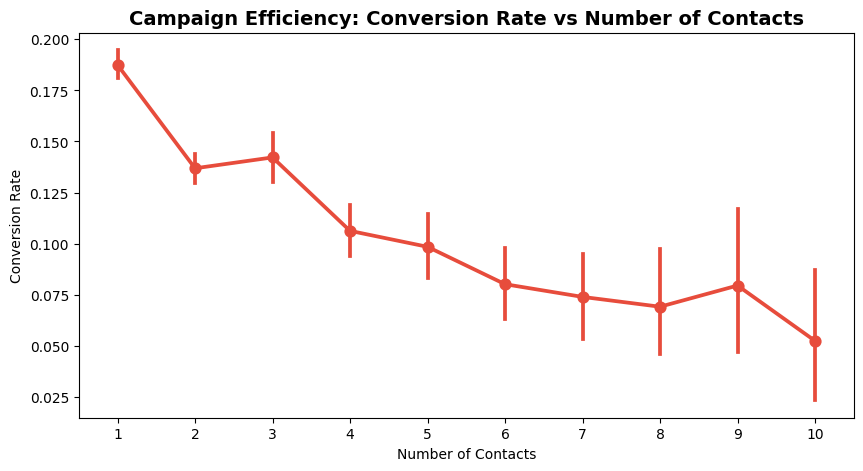

In [ ]:
# Campaign Saturation Analysis
plt.figure(figsize=(10,5))

filtered_df = df[df['campaign'] <= 10]

sns.pointplot(x='campaign', y='conversion', data=filtered_df, color='#E74C3C')

plt.title('Campaign Efficiency: Conversion Rate vs Number of Contacts', fontsize=14, fontweight='bold')
plt.xlabel('Number of Contacts')
plt.ylabel('Conversion Rate')

plt.show()

The conversion rate is highest at the first contact, reaching approximately 18.7%. However, it drops significantly to around 13–14% on the second and third contacts.

As the number of contacts increases further, the conversion rate continues to decline, falling to around 10.6% on the fourth contact and dropping below 8% after the sixth contact.

At higher contact frequencies (8–10 contacts), the conversion rate decreases even further to approximately 5–8%, indicating a substantial reduction in effectiveness.

## Hypothesis Testing

**Objective**

To evaluate whether the communication channel (contact type) significantly influences customer subscription, as assumed by management.

**Hypotheses**
H0 (Null Hypothesis):
There is no relationship between contact type and customer subscription

H1 (Alternative Hypothesis):
There is a relationship between contact type and customer subscription

**Method**

A Chi-Square Test of Independence was conducted, as both variables are categorical and the goal is to assess whether they are statistically associated.

In [ ]:
# Testing
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['contact'], df['y'])
chi2, p, dof, expected = chi2_contingency(contingency)

print("p-value:", p)

p-value: 0.01435100646162061


The result shows a statistically significant relationship between contact type and customer subscription (p < 0.05). **This indicates that the communication channel plays an important role in influencing customer decisions.**

## Recommendation

Based on the analysis, several strategic actions can be taken to improve marketing effectiveness:

* Focus on call quality rather than quantity
Since longer call duration is strongly associated with higher conversion, efforts should be directed toward improving customer engagement during interactions rather than increasing the number of contacts.
* Limit excessive contact attempts
Conversion rates decline significantly after multiple contacts. Therefore, the number of contact attempts should be optimized, ideally within 1–3 contacts, to avoid customer fatigue and maintain effectiveness.
* Prioritize high-potential customer segments
Target customers with higher financial capacity (e.g., higher balance) and favorable demographic profiles (e.g., students, retirees, and higher education levels) to increase conversion rates.
Leverage historical customer interactions
Customers with successful previous campaigns show significantly higher conversion rates. These customers should be prioritized in future campaigns.
* Optimize communication channels
Since contact type has a statistically significant impact, more effective channels (e.g., cellular) should be prioritized to improve customer response.
* Schedule campaigns during high-performing periods
Campaigns should be strategically conducted during months with higher conversion rates (e.g., March, September, and December) to maximize effectiveness.